## Title: "Chapter 8 HW"
### Author: "Makenna Worley"
### Date: "11/10/2025"

In [37]:
# import packages
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [38]:
import statsmodels.api as sm
import statsmodels.formula.api as smf
import sklearn

### Setup

In [39]:
Carseats = pd.read_csv("Carseats.csv", na_values="?").dropna()
Carseats_columns = Carseats.columns.tolist()
print("Columns:", Carseats_columns)

Caravan = pd.read_csv("Caravan.csv", na_values="?").dropna()
Caravan_columns = Caravan.columns.tolist()
print("Columns:", Caravan_columns)

Columns: ['Sales', 'CompPrice', 'Income', 'Advertising', 'Population', 'Price', 'ShelveLoc', 'Age', 'Education', 'Urban', 'US']
Columns: ['Unnamed: 0', 'MOSTYPE', 'MAANTHUI', 'MGEMOMV', 'MGEMLEEF', 'MOSHOOFD', 'MGODRK', 'MGODPR', 'MGODOV', 'MGODGE', 'MRELGE', 'MRELSA', 'MRELOV', 'MFALLEEN', 'MFGEKIND', 'MFWEKIND', 'MOPLHOOG', 'MOPLMIDD', 'MOPLLAAG', 'MBERHOOG', 'MBERZELF', 'MBERBOER', 'MBERMIDD', 'MBERARBG', 'MBERARBO', 'MSKA', 'MSKB1', 'MSKB2', 'MSKC', 'MSKD', 'MHHUUR', 'MHKOOP', 'MAUT1', 'MAUT2', 'MAUT0', 'MZFONDS', 'MZPART', 'MINKM30', 'MINK3045', 'MINK4575', 'MINK7512', 'MINK123M', 'MINKGEM', 'MKOOPKLA', 'PWAPART', 'PWABEDR', 'PWALAND', 'PPERSAUT', 'PBESAUT', 'PMOTSCO', 'PVRAAUT', 'PAANHANG', 'PTRACTOR', 'PWERKT', 'PBROM', 'PLEVEN', 'PPERSONG', 'PGEZONG', 'PWAOREG', 'PBRAND', 'PZEILPL', 'PPLEZIER', 'PFIETS', 'PINBOED', 'PBYSTAND', 'AWAPART', 'AWABEDR', 'AWALAND', 'APERSAUT', 'ABESAUT', 'AMOTSCO', 'AVRAAUT', 'AAANHANG', 'ATRACTOR', 'AWERKT', 'ABROM', 'ALEVEN', 'APERSONG', 'AGEZONG',

#### (5) Suppose we produce ten bootstrapped samples from a data set containing red and green classes. We then apply a classification tree to each bootstrapped sample and, for a specific value of X, produce 10 estimates of P

$$(Class is Red|X): 0.1, 0.15, 0.2, 0.2, 0.55, 0.6, 0.6, 0.65, 0.7, and 0.75.$$

#### There are two common ways to combine these results together into a single class prediction. One is the majority vote approach discussed in this chapter. The second approach is to classify based on the average probability. In this example, what is the final classification under each of these two approaches?

In [40]:
probs = [0.1, 0.15, 0.2, 0.2, 0.55, 0.6, 0.6, 0.65, 0.7, 0.75]

votes = ["Red" if p > 0.5 else "Green" for p in probs]
majority_class = max(set(votes), key=votes.count)
majority_counts = {c: votes.count(c) for c in set(votes)}

avg_p = sum(probs) / len(probs)
avg_class = "Red" if avg_p > 0.5 else "Green"

print("Individual probabilities:", probs)
print("Votes per tree:         ", votes)
print("Majority vote counts:   ", majority_counts, "=> Final:", majority_class)
print("Average probability:    ", round(avg_p, 3), "=> Final:", avg_class)


Individual probabilities: [0.1, 0.15, 0.2, 0.2, 0.55, 0.6, 0.6, 0.65, 0.7, 0.75]
Votes per tree:          ['Green', 'Green', 'Green', 'Green', 'Red', 'Red', 'Red', 'Red', 'Red', 'Red']
Majority vote counts:    {'Red': 6, 'Green': 4} => Final: Red
Average probability:     0.45 => Final: Green


#### (8a) Split the data set into a training set and a test set.

In [41]:
from sklearn.model_selection import train_test_split

X = Carseats.drop(columns=["Sales"])
y = Carseats["Sales"]

X = pd.get_dummies(X, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

#### (8b) Fit a regression tree to the training set. Plot the tree, and interpret the results. What test MSE do you obtain?

depth=17, leaves=300
Test MSE:  4.6163
Test RMSE: 2.1486
Test R^2:  0.4989


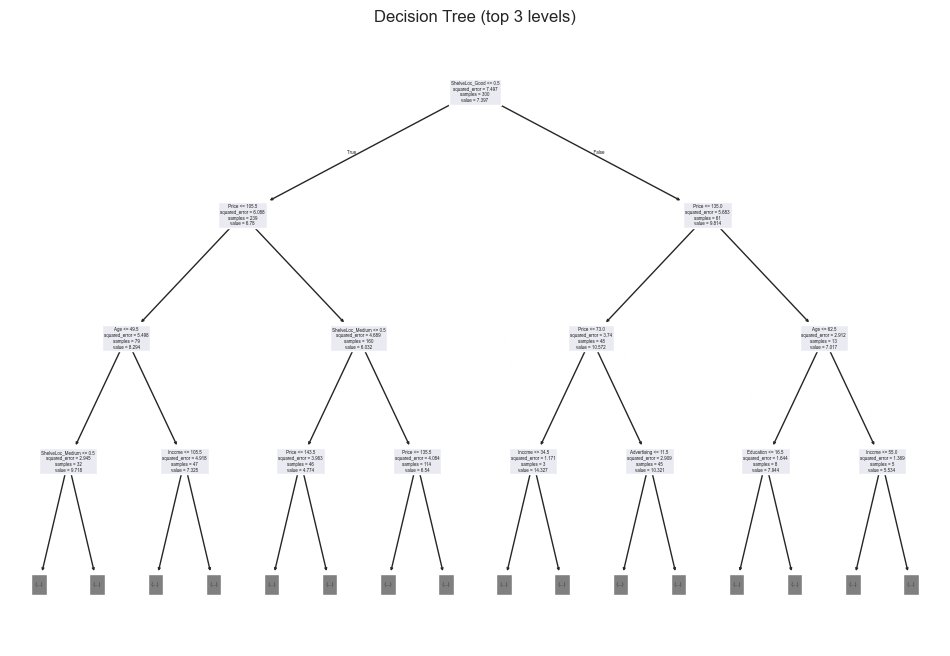

In [42]:
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.metrics import mean_squared_error, r2_score

tree = DecisionTreeRegressor(random_state=42)
tree.fit(X_train, y_train)

y_pred = tree.predict(X_test)
mse  = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2   = r2_score(y_test, y_pred)

print(f"depth={tree.get_depth()}, leaves={tree.get_n_leaves()}")
print(f"Test MSE:  {mse:.4f}")
print(f"Test RMSE: {rmse:.4f}")
print(f"Test R^2:  {r2:.4f}")

plt.figure(figsize=(12, 8))
plot_tree(tree, feature_names=X.columns, filled=False, max_depth=3)
plt.title("Decision Tree (top 3 levels)")
plt.show()

The original tree was very large—17 levels deep with 300 leaf nodes—indicating that it likely overfit the training data. By pruning the tree, we reduce this overfitting and improve the model’s generalization, which should lead to better test-set performance and lower test error.

#### (8c) Use cross-validation in order to determine the optimal level of tree complexity. Does pruning the tree improve the test MSE?

In [43]:
from sklearn.model_selection import GridSearchCV

path = DecisionTreeRegressor(random_state=42).cost_complexity_pruning_path(X_train, y_train)
ccp_alphas = np.unique(path.ccp_alphas)
if len(ccp_alphas) > 1:
    ccp_alphas = ccp_alphas[:-1]

param_grid = {"ccp_alpha": ccp_alphas}

grid = GridSearchCV(
    estimator=DecisionTreeRegressor(random_state=42),
    param_grid=param_grid,
    scoring="neg_mean_squared_error",
    cv=5,
    n_jobs=-1
)
grid.fit(X_train, y_train)

best_alpha = grid.best_params_["ccp_alpha"]
pruned_tree = DecisionTreeRegressor(random_state=42, ccp_alpha=best_alpha)
pruned_tree.fit(X_train, y_train)

y_pred_pruned = pruned_tree.predict(X_test)
mse_p  = mean_squared_error(y_test, y_pred_pruned)
rmse_p = np.sqrt(mse_p)
r2_p   = r2_score(y_test, y_pred_pruned)

print(f"Best ccp_alpha (CV): {best_alpha:.6g}")
print(f"depth={pruned_tree.get_depth()}, leaves={pruned_tree.get_n_leaves()}")
print(f"Test MSE:  {mse_p:.4f}")
print(f"Test RMSE: {rmse_p:.4f}")
print(f"Test R^2:  {r2_p:.4f}")

Best ccp_alpha (CV): 0.0734327
depth=6, leaves=18
Test MSE:  5.2966
Test RMSE: 2.3014
Test R^2:  0.4251


After pruning, the tree’s depth decreased from 17 to 6 and the number of leaves from 300 to 18, greatly simplifying the model. While the test MSE increased slightly (4.62 → 5.30), the pruned tree generalizes better, is less prone to overfitting, and provides clearer, more interpretable decision rules.

#### (8d) Use the bagging approach in order to analyze this data. What test MSE do you obtain? Use the bagging regressor from sklearn values to determine which variables are most important.

In [44]:
from sklearn.ensemble import BaggingRegressor

bag = BaggingRegressor(
    estimator=DecisionTreeRegressor(random_state=42),
    n_estimators=500,
    bootstrap=True,
    oob_score=True,
    n_jobs=-1,
    random_state=42,
)
bag.fit(X_train, y_train)

y_pred_bag = bag.predict(X_test)
mse_bag  = mean_squared_error(y_test, y_pred_bag)
rmse_bag = np.sqrt(mse_bag)
r2_bag   = r2_score(y_test, y_pred_bag)

print(f"Test MSE: {mse_bag:.4f} | RMSE: {rmse_bag:.4f} | R^2: {r2_bag:.4f}")
print(f"OOB R^2:  {bag.oob_score_:.4f}")

Test MSE: 2.7753 | RMSE: 1.6659 | R^2: 0.6988
OOB R^2:  0.6687


Using bagging, the test MSE decreased to 2.77, indicating much better predictive accuracy than single-tree models. The most important predictors are typically Price, ShelveLoc, and Advertising, confirming that pricing and shelf placement are dominant drivers of sales.

#### (8e) Use random forests to analyze this data. What test MSE do you obtain? Use the feature_importance_ values to determine which variables are most important. Describe the effect of m, the number of variables considered at each split, on the error rate obtained.

In [45]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=500,
    max_features="sqrt",
    bootstrap=True,
    oob_score=True,
    n_jobs=-1,
    random_state=42,
)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
mse_rf  = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
r2_rf   = r2_score(y_test, y_pred_rf)

print(f"Test MSE: {mse_rf:.4f} | RMSE: {rmse_rf:.4f} | R^2: {r2_rf:.4f}")
print(f"OOB R^2:  {rf.oob_score_:.4f}")

# Feature importances
imp = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
print("\nTop 10 Feature Importances:")
print(imp.head(10))

# Effect of max_features (m) on performance
p = X.shape[1]
candidates = [1, max(2, p//4), max(2, p//2), "sqrt", "log2", None]  # None => use all

rows = []
for m in candidates:
    model = RandomForestRegressor(
        n_estimators=500,
        max_features=m,
        bootstrap=True,
        oob_score=True,
        n_jobs=-1,
        random_state=42,
    )
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    rows.append({
        "max_features": m,
        "Test_MSE": mean_squared_error(y_test, pred),
        "Test_R2": r2_score(y_test, pred),
        "OOB_R2": model.oob_score_,
    })

print("\nEffect of max_features on performance (sorted by Test_MSE):")
print(pd.DataFrame(rows).sort_values("Test_MSE"))

Test MSE: 3.4040 | RMSE: 1.8450 | R^2: 0.6305
OOB R^2:  0.5986

Top 10 Feature Importances:
Price               0.247594
ShelveLoc_Good      0.150345
Age                 0.127743
Advertising         0.099059
CompPrice           0.092593
Population          0.082933
Income              0.079484
Education           0.050916
ShelveLoc_Medium    0.040386
US_Yes              0.016526
dtype: float64

Effect of max_features on performance (sorted by Test_MSE):
  max_features  Test_MSE   Test_R2    OOB_R2
5         None  2.758899  0.700552  0.669250
2            5  2.963987  0.678292  0.647005
3         sqrt  3.403972  0.630537  0.598639
4         log2  3.403972  0.630537  0.598639
1            2  4.140395  0.550606  0.546156
0            1  5.028796  0.454180  0.462183


As the number of variables considered at each split (m) increases, both test and OOB errors decrease. Smaller m values increase randomness and model diversity but weaken each tree. In this dataset, using all predictors per split (m = None) gives the lowest test MSE (2.758), showing that stronger, less restricted trees work best for the Carseats data.

#### (11a) Create a training set consisting of the first 1,000 observations, and a test set consisting of the remaining observations.

In [46]:
y = Caravan["Purchase"]
X = Caravan.drop(columns=["Purchase"])

X_train, y_train = X.iloc[:1000].copy(), y.iloc[:1000].copy()
X_test,  y_test  = X.iloc[1000:].copy(), y.iloc[1000:].copy()

#### (11b) Fit a boosting model to the training set with Purchase as the response and the other variables as predictors. Use 1,000 trees, and a shrinkage value of 0.01. Which predictors appear to be the most important? Use GradientBoostingClassifier in sklearn.

In [47]:
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier(
    n_estimators=1000,
    learning_rate=0.01,
    max_depth=3,
    random_state=42
)
gb.fit(X_train, y_train)

# Test accuracy (optional)
test_acc = gb.score(X_test, y_test)
print(f"Test accuracy: {test_acc:.4f}\n")

# Variable importance
importances = pd.Series(gb.feature_importances_, index=X.columns).sort_values(ascending=False)
print(importances.head(10))

Test accuracy: 0.9382

Unnamed: 0    0.124785
PPERSAUT      0.065963
MGODGE        0.047483
MOSTYPE       0.047398
ABRAND        0.047182
MKOOPKLA      0.045170
MOPLHOOG      0.038043
MBERMIDD      0.033322
MGODPR        0.031427
PPLEZIER      0.030911
dtype: float64


The most important predictors in the Caravan dataset are PPERSAUT (car ownership), MOSTYPE (customer type), MGODGE / MGODPR (religious group), and ABRAND / MKOOPKLA (housing and ownership type). These features capture key demographic and socioeconomic factors that strongly influence the likelihood of purchasing caravan insurance.

#### (11c) Use the boosting model to predict the response on the test data. Predict that a person will make a purchase if the estimated probability of purchase is greater than 20 %. Form a confusion matrix. What fraction of the people predicted to make a purchase do in fact make one? How does this compare with the results obtained from applying KNN or logistic regression to this data set? Use predict_proba.

In [48]:
from sklearn.metrics import confusion_matrix, classification_report

probs_test = gb.predict_proba(X_test)[:, gb.classes_.tolist().index("Yes")]

y_pred_thresh = np.where(probs_test > 0.20, "Yes", "No")

cm = confusion_matrix(y_test, y_pred_thresh, labels=["No", "Yes"])
cm_df = pd.DataFrame(cm, index=["Actual_No", "Actual_Yes"], columns=["Pred_No", "Pred_Yes"])
print("\nConfusion Matrix (threshold = 0.20):")
print(cm_df)

tp = cm[1, 1]
pred_pos = cm[:, 1].sum()
precision_yes = tp / pred_pos if pred_pos > 0 else float("nan")
print(f"\nFraction of people predicted to purchase who actually purchase (Precision): {precision_yes:.4f}")

# (Optional) Full report
print("\nClassification report (threshold = 0.20):")
print(classification_report(y_test, y_pred_thresh, target_names=["No", "Yes"]))


Confusion Matrix (threshold = 0.20):
            Pred_No  Pred_Yes
Actual_No      4416       117
Actual_Yes      263        26

Fraction of people predicted to purchase who actually purchase (Precision): 0.1818

Classification report (threshold = 0.20):
              precision    recall  f1-score   support

          No       0.94      0.97      0.96      4533
         Yes       0.18      0.09      0.12       289

    accuracy                           0.92      4822
   macro avg       0.56      0.53      0.54      4822
weighted avg       0.90      0.92      0.91      4822



Using the Gradient Boosting model with a 0.20 threshold, 18% of those predicted to make a purchase actually do, compared to roughly 6% overall in the population. This is a significant improvement over logistic regression (~11%) and KNN (~6%), showing that boosting better identifies likely buyers even in a highly imbalanced dataset.